In [10]:
import numpy as np
from skimage.metrics import structural_similarity

def MSE(pred, true):
    return np.mean((pred - true) ** 2, axis=(0, 1)).sum()


def compute_metrics(predictions, targets):
    targets = targets.transpose(0, 1, 3, 4, 2)
    predictions = predictions.transpose(0, 1, 3, 4, 2)

    batch_size = predictions.shape[0]
    Seq_len = predictions.shape[1]

    ssim = 0

    for batch in range(batch_size):
        for frame in range(Seq_len):
            # 从数组中取出当前帧
            target_frame = targets[batch, frame].squeeze()
            prediction_frame = predictions[batch, frame].squeeze()
            # !! 关键步骤：将 prediction 裁剪到 [0, 1] 范围 !!
            prediction_frame_clipped = np.clip(prediction_frame, 0, 1)
            # 现在，两个输入的范围都是 [0, 1] 了
            # data_range 应该设置为 1.0
            ssim += structural_similarity(target_frame,
                                        prediction_frame_clipped,
                                        data_range=1.0,)

    ssim /= (batch_size * Seq_len)

    mse = MSE(predictions, targets)

    return mse, ssim

In [19]:
root = '/nas_data/LSH/OpenSTL-MOR/work_dirs/kth/simvp/modvit/saved'
preds = np.load(root + '/preds.npy')
trues = np.load(root + '/trues.npy')
print(f'preds shape: {preds.shape}, trues shape: {trues.shape}')
# --- 检查数据范围和类型的代码 ---
print("--- 检查 'predictions' (preds.npy) ---")
print(f"数据类型 (dtype): {preds.dtype}")
print(f"最大值 (max): {np.max(preds)}")
print(f"最小值 (min): {np.min(preds)}")
print("-" * 30) # 分隔符

print("\n--- 检查 'targets' (trues.npy) ---")
print(f"数据类型 (dtype): {trues.dtype}")
print(f"最大值 (max): {np.max(trues)}")
print(f"最小值 (min): {np.min(trues)}")
print("-" * 30) # 分隔符
mse, ssim = compute_metrics(preds, trues)
print(f'MSE: {mse}, SSIM: {ssim}')

preds shape: (3167, 20, 1, 128, 128), trues shape: (3167, 20, 1, 128, 128)
--- 检查 'predictions' (preds.npy) ---
数据类型 (dtype): float32
最大值 (max): 3.669084310531616
最小值 (min): -5.9647908210754395
------------------------------

--- 检查 'targets' (trues.npy) ---
数据类型 (dtype): float32
最大值 (max): 1.0
最小值 (min): 0.0
------------------------------
MSE: 57.902915954589844, SSIM: 0.7931064008501464


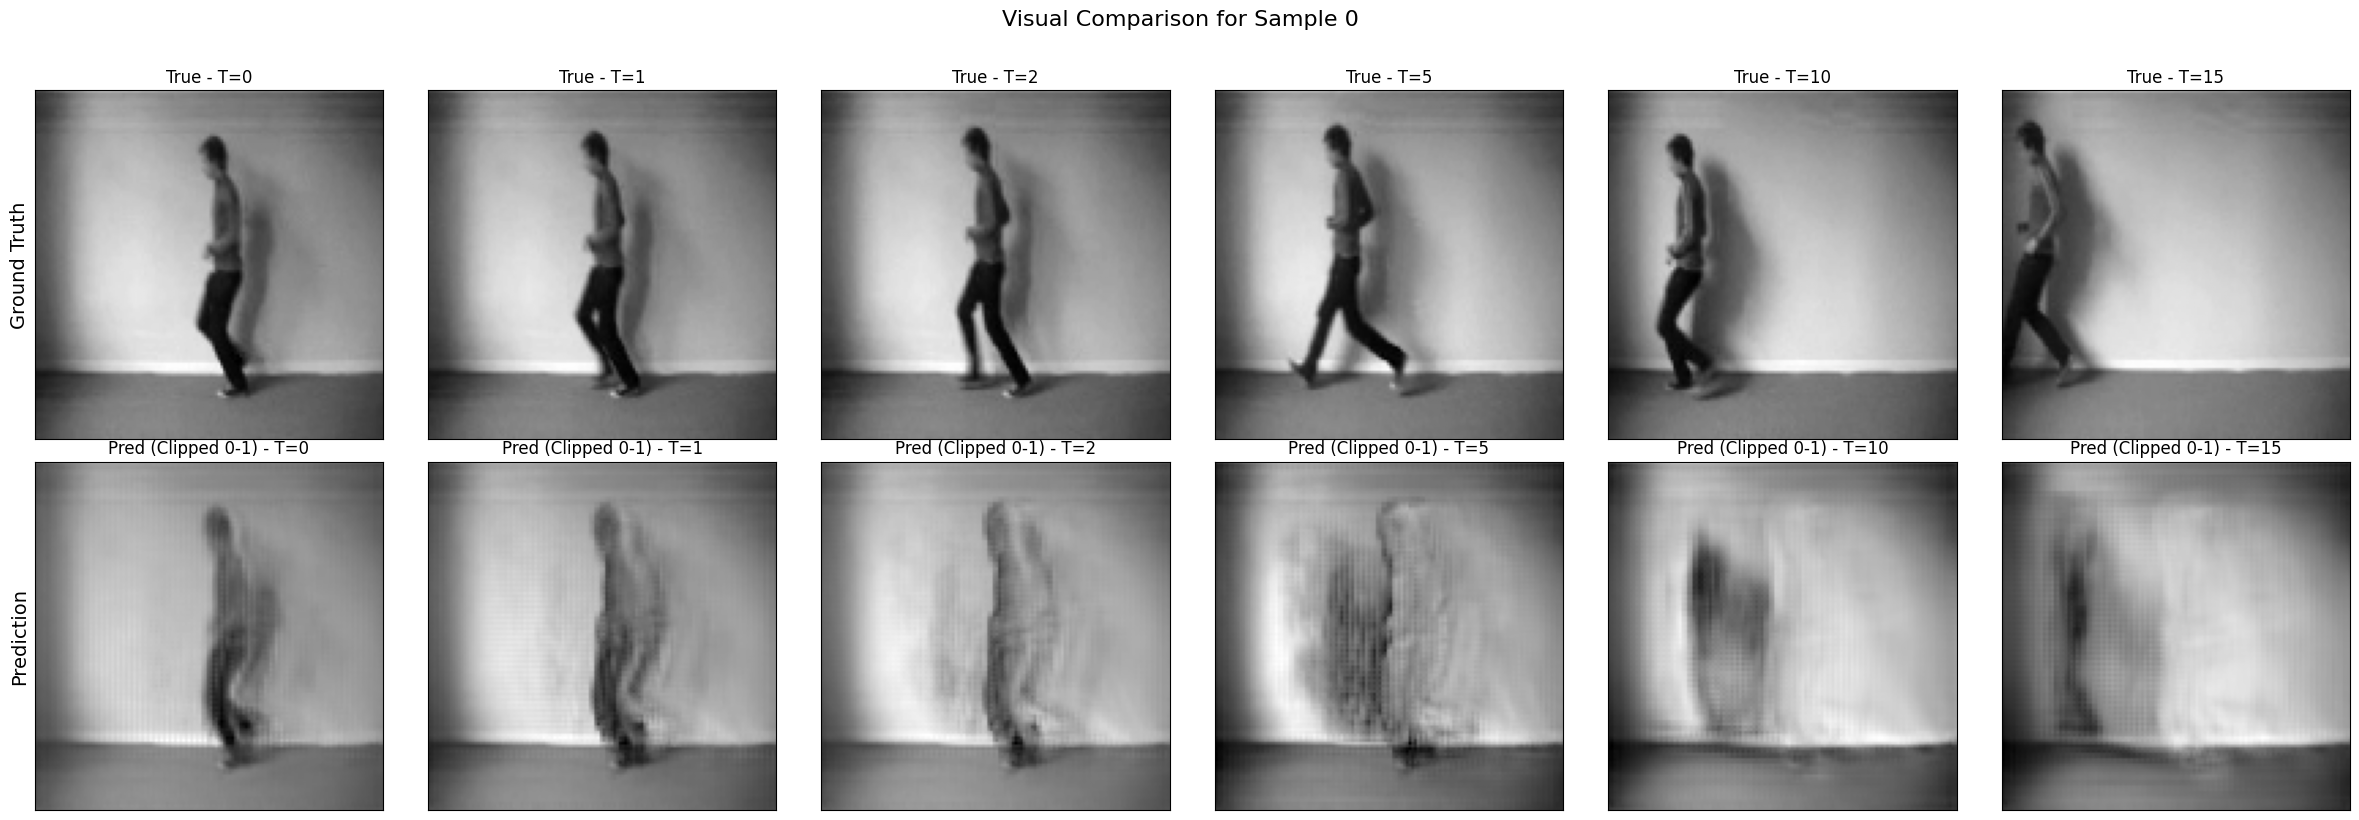

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 假设 preds 和 trues 已经被加载，且 shape 为 (3167, 20, 1, 128, 128)

# -----------------
# 1. 设置可视化参数
sample_idx = 0  # 选择第 0 个样本（视频序列）
time_steps_to_plot = [0, 1, 2, 5, 10, 15] # 选择要对比的几个时间步（帧）
num_frames_to_show = len(time_steps_to_plot)

# -----------------
# 2. 创建子图
# 行数 = 2 (真实值 vs 预测值)
# 列数 = 要对比的帧数 (num_frames_to_show)
fig, axes = plt.subplots(
    nrows=2, 
    ncols=num_frames_to_show, 
    figsize=(4 * num_frames_to_show, 8) # 调整 figsize 使图片不会太扁
)

# -----------------
# 3. 遍历选定的时间步并绘图
for i, t in enumerate(time_steps_to_plot):
    
    # 提取数据：切片去除 通道(0) 维度，得到 (128, 128)
    true_frame = trues[sample_idx, t, 0, :, :]
    
    # 对预测值进行截断处理
    pred_frame_raw = preds[sample_idx, t, 0, :, :]

    # --- 第一行: 真实值 (Trues) ---
    ax_true = axes[0, i]
    # 注意：真实值也使用 [0, 1] 范围进行颜色映射，以保持一致性
    ax_true.imshow(true_frame, cmap='gray',) 
    ax_true.set_title(f'True - T={t}', fontsize=12)
    ax_true.set_xticks([])
    ax_true.set_yticks([])
    
    # 只在第一列添加行标签
    if i == 0:
        ax_true.set_ylabel('Ground Truth', rotation=90, fontsize=14)

    # --- 第二行: 预测值 (Predictions) ---
    ax_pred = axes[1, i]
    ax_pred.imshow(pred_frame_raw, cmap='gray')
    ax_pred.set_title(f'Pred (Clipped 0-1) - T={t}', fontsize=12)
    ax_pred.set_xticks([])
    ax_pred.set_yticks([])
    
    # 只在第一列添加行标签
    if i == 0:
        ax_pred.set_ylabel('Prediction', rotation=90, fontsize=14)

# 4. 调整布局并显示
fig.suptitle(f'Visual Comparison for Sample {sample_idx}', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1.0]) # 调整以容纳 suptitle
plt.show()